In [1]:
import os
import re
import abc
import sys
import yaml
import copy
import math
import wandb
import torch
import random
import pydicom
import weakref
import logging
import argparse
import itertools
import functools
import numpy as np
import pandas as pd
import torch.nn as nn
import albumentations
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torch.utils.model_zoo as model_zoo

from tqdm import tqdm
from PIL import Image
from glob import glob
from pathlib import Path
from shutil import copyfile
from functools import reduce
from datetime import datetime
from torch.backends import cudnn
from typing import List, Optional
from abc import ABC, abstractmethod
from torch.utils.data import Dataset
from torch.utils.data.sampler import Sampler
from typing import List, Type, Dict, Optional
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split
from torch.optim.lr_scheduler import ReduceLROnPlateau
from collections import deque, defaultdict, OrderedDict
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score

In [2]:
scripts_conf = """
data_folder: "/kaggle/input/competitions/rsna-intracranial-hemorrhage-detection" # target directory 
raw_data_folder: "/kaggle/input/competitions/rsna-intracranial-hemorrhage-detection" # directory of your original dataset
output_folder: "/kaggle/working"
client_num: 5
dirichlet_alpha: 1.0
seed: 523

resize:
  height: 224
  width: 224

unlearn_client: 0
"""

with open("scripts_conf.yaml", "w") as f:
    f.write(scripts_conf)

In [3]:
config_path = "scripts_conf.yaml"

# Load YAML config
with open(config_path, "r") as file:
    config = yaml.safe_load(file)

# Extract values
data_folder = ["data_folder"]
raw_data_folder = config["raw_data_folder"]
output_folder = config["output_folder"]
client_num = config["client_num"]
dirichlet_alpha = config["dirichlet_alpha"]
seed = config["seed"]
resize_height = config["resize"]["height"]
resize_width = config["resize"]["width"]
unlearn_client = config["unlearn_client"]

print(f"Loaded config: {config}")

Loaded config: {'data_folder': '/kaggle/input/competitions/rsna-intracranial-hemorrhage-detection', 'raw_data_folder': '/kaggle/input/competitions/rsna-intracranial-hemorrhage-detection', 'output_folder': '/kaggle/working', 'client_num': 5, 'dirichlet_alpha': 1.0, 'seed': 523, 'resize': {'height': 224, 'width': 224}, 'unlearn_client': 0}


In [4]:
all_xray_df = pd.read_csv(f'{raw_data_folder}/rsna-intracranial-hemorrhage-detection/stage_2_train.csv')

label = all_xray_df.Label.values
all_xray_df = all_xray_df.ID.str.rsplit("_", n=1, expand=True)
all_xray_df.loc[:, "label"] = label
all_xray_df = all_xray_df.rename({0: "id", 1: "subtype"}, axis=1)

all_xray_df = pd.pivot_table(all_xray_df, index="id", columns="subtype", values="label").reset_index()

all_xray_df['healthy'] = (all_xray_df['any'] == 0).astype(int)
all_xray_df.drop('any', axis=1, inplace=True)

# randomly sample 25000 images
healthy_sample = all_xray_df[all_xray_df['healthy'] == 1].sample(n=5000, random_state=1)
unhealthy_sample = all_xray_df[all_xray_df['healthy'] == 0].sample(n=5000, random_state=1)

balanced_sampled_df = pd.concat([healthy_sample, unhealthy_sample])

healthy_count = balanced_sampled_df['healthy'].sum()
unhealthy_count = balanced_sampled_df.shape[0] - healthy_count

print(f"Healthy: {healthy_count}")
print(f"Unhealthy: {unhealthy_count}")

all_image_paths = {Path(x).stem: x for x in glob(os.path.join(raw_data_folder, 'rsna*', '*', '*.dcm'))}

balanced_sampled_df['path'] = balanced_sampled_df['id'].map(all_image_paths.get)

output_dir = f'{output_folder}/resized'
Path(output_dir).mkdir(exist_ok=True)

def convert_dicom_to_png(dicom_path, output_path, target_size=(224, 224)):
    # read dicom
    dicom_image = pydicom.dcmread(dicom_path)
    image_array = dicom_image.pixel_array
    image_array = np.interp(image_array, (image_array.min(), image_array.max()), (0, 255))
    image_array = image_array.astype(np.uint8)
    image = Image.fromarray(image_array)
    # resize
    image = image.resize(target_size, Image.Resampling.LANCZOS)
    image.save(output_path, format='png')

for index, row in balanced_sampled_df.iterrows():
    dicom_path = row['path']
    output_path = os.path.join(output_dir, f"{row['id']}.png")
    convert_dicom_to_png(dicom_path, output_path)
    balanced_sampled_df.at[index, 'path'] = output_path

balanced_sampled_df.to_csv(f'{output_folder}/balanced_sampled.csv', index=False)

Healthy: 5000
Unhealthy: 5000


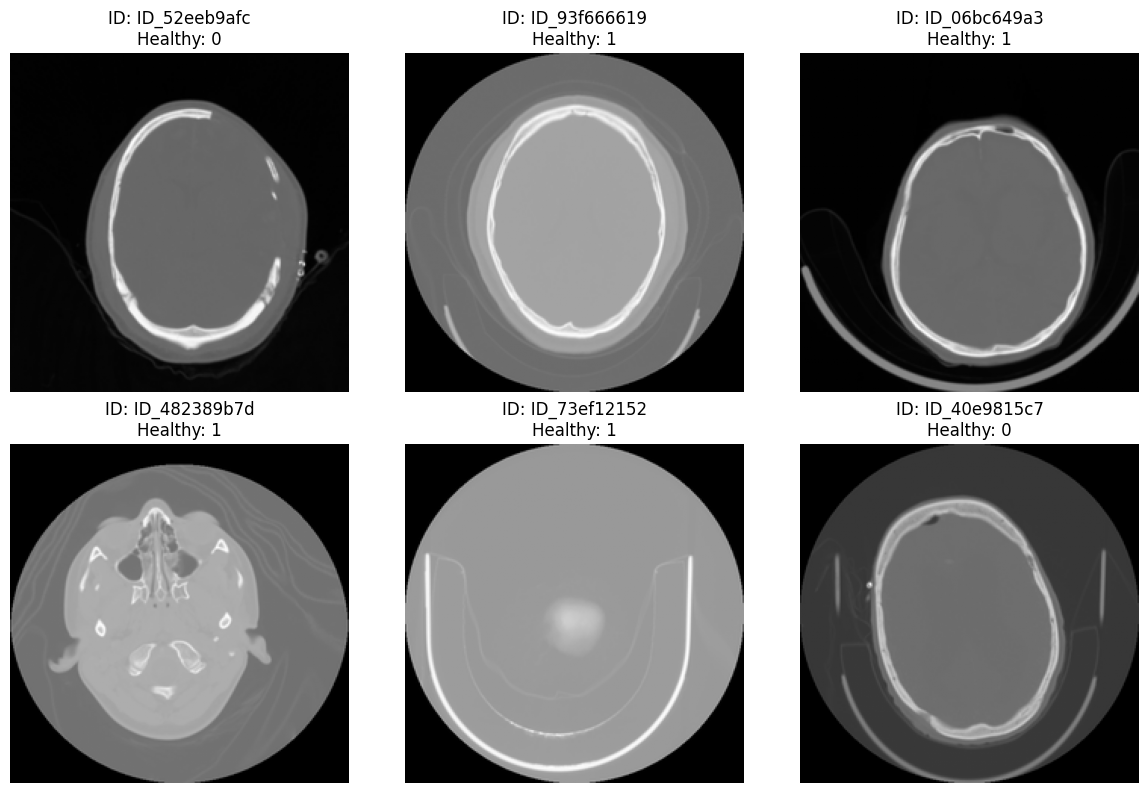

In [5]:
sample_rows = balanced_sampled_df.sample(n=6, random_state=42)

# Plot them
plt.figure(figsize=(12, 8))
for i, (_, row) in enumerate(sample_rows.iterrows()):
    img = Image.open(row['path'])
    plt.subplot(2, 3, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"ID: {row['id']}\nHealthy: {row['healthy']}")
    plt.axis('off')

plt.tight_layout()
plt.show()

# Generate FL datasets

In [6]:
# sample_dirichlet.py

def clients_indices(list_label2indices: list, num_classes: int, num_clients: int, non_iid_alpha: float, seed=None):
    indices2targets = []
    for label, indices in enumerate(list_label2indices):
        for idx in indices:
            indices2targets.append((idx, label))

    batch_indices = build_non_iid_by_dirichlet(seed=seed,
                                               indices2targets=indices2targets,
                                               non_iid_alpha=non_iid_alpha,
                                               num_classes=num_classes,
                                               num_indices=len(indices2targets),
                                               n_workers=num_clients)
    indices_dirichlet = functools.reduce(lambda x, y: x + y, batch_indices)
    list_client2indices = partition_balance(indices_dirichlet, num_clients)

    return list_client2indices


def partition_balance(idxs, num_split: int):

    num_per_part, r = len(idxs) // num_split, len(idxs) % num_split
    parts = []
    i, r_used = 0, 0
    while i < len(idxs):
        if r_used < r:
            parts.append(idxs[i:(i + num_per_part + 1)])
            i += num_per_part + 1
            r_used += 1
        else:
            parts.append(idxs[i:(i + num_per_part)])
            i += num_per_part

    return parts


def build_non_iid_by_dirichlet(
    seed, indices2targets, non_iid_alpha, num_classes, num_indices, n_workers
):
    random_state = np.random.RandomState(seed)
    n_auxi_workers = 5
    assert n_auxi_workers <= n_workers

    # random shuffle targets indices.
    random_state.shuffle(indices2targets)

    # partition indices.
    from_index = 0
    splitted_targets = []

    num_splits = math.ceil(n_workers / n_auxi_workers)

    split_n_workers = [
        n_auxi_workers
        if idx < num_splits - 1
        else n_workers - n_auxi_workers * (num_splits - 1)
        for idx in range(num_splits)
    ]
    split_ratios = [_n_workers / n_workers for _n_workers in split_n_workers]
    for idx, ratio in enumerate(split_ratios):
        to_index = from_index + int(n_auxi_workers / n_workers * num_indices)
        splitted_targets.append(
            indices2targets[
                from_index: (num_indices if idx == num_splits - 1 else to_index)
            ]
        )
        from_index = to_index

    #
    idx_batch = []
    for _targets in splitted_targets:
        # rebuild _targets.
        _targets = np.array(_targets)
        _targets_size = len(_targets)

        # use auxi_workers for this subset targets.
        _n_workers = min(n_auxi_workers, n_workers)
        #n_workers=10
        n_workers = n_workers - n_auxi_workers

        # get the corresponding idx_batch.
        min_size = 0
        _idx_batch = None
        while min_size < int(0.50 * _targets_size / _n_workers):
            _idx_batch = [[] for _ in range(_n_workers)]
            for _class in range(num_classes):
                # get the corresponding indices in the original 'targets' list.
                idx_class = np.where(_targets[:, 1] == _class)[0]
                idx_class = _targets[idx_class, 0]

                # sampling.
                try:
                    proportions = random_state.dirichlet(
                        np.repeat(non_iid_alpha, _n_workers)
                    )
                    # balance
                    proportions = np.array(
                        [
                            p * (len(idx_j) < _targets_size / _n_workers)
                            for p, idx_j in zip(proportions, _idx_batch)
                        ]
                    )
                    proportions = proportions / proportions.sum()
                    proportions = (np.cumsum(proportions) * len(idx_class)).astype(int)[
                        :-1
                    ]
                    _idx_batch = [
                        idx_j + idx.tolist()
                        for idx_j, idx in zip(
                            _idx_batch, np.split(idx_class, proportions)
                        )
                    ]
                    sizes = [len(idx_j) for idx_j in _idx_batch]
                    min_size = min([_size for _size in sizes])
                except ZeroDivisionError:
                    pass
        if _idx_batch is not None:
            idx_batch += _idx_batch

    return idx_batch

In [7]:
#ich_prepare_fl.py

# data_folder = config.get("data_folder", "~/data/ich")
# raw_data_folder = config.get("raw_data_folder", f"{data_folder}/raw")
# client_num = config.get("client_num", 6)
# dirichlet_alpha = config.get("dirichlet_alpha", 0.5) 
# random.seed(config.get("seed", 0))

class_names =  ["healthy"]

target_folder = f'{output_folder}/fedmu'
Path(target_folder).mkdir(parents=True, exist_ok=True)

all_xray_df = pd.read_csv(f'{output_folder}/balanced_sampled.csv')

class_num = len(class_names) * 2

train_ratio = 0.7
val_ratio = 0.1
test_ratio = 0.2

train, test = train_test_split(all_xray_df,test_size=test_ratio, random_state=config.get("seed", 0))
train, val = train_test_split(train,test_size=val_ratio/(train_ratio+val_ratio), random_state=config.get("seed", 0))

test.to_csv(f'{target_folder}/test.csv', index=False)
val.to_csv(f'{target_folder}/val.csv', index=False)

# split the training data into clients by the dirichlet distribution
list_label2indices = []
for class_name in class_names:
    healthy_indices = train[train[class_name] == 1].index.tolist()
    list_label2indices.append(healthy_indices)
    
    unhealthy_indices = train[train[class_name] == 0].index.tolist()
    list_label2indices.append(unhealthy_indices)

client_indices = clients_indices(
    list_label2indices=list_label2indices,
    num_classes=class_num,
    num_clients=client_num,
    non_iid_alpha=dirichlet_alpha,
    seed=config.get("seed", 0)
)

for client_id, indices in enumerate(client_indices):
    client_df = all_xray_df.loc[indices]
    Path(target_folder).joinpath(f'client_{client_id}').mkdir(parents=True, exist_ok=True)
    client_df.to_csv(f'{target_folder}/client_{client_id}/train.csv', index=False)


def get_distribution(df):
    healthy_count = df['healthy'].sum()
    total_count = len(df)
    unhealthy_count = total_count - healthy_count  
    
    distribution = {
        "healthy": healthy_count,
        "unhealthy": unhealthy_count
    }
    
    return distribution


# Assuming client_indices is a list of lists, where each inner list contains the indices for a client
distribution = {}

for client_id, indices in enumerate(client_indices):
    client_df = all_xray_df.loc[indices]
    # Use the get_distribution function to get the counts of healthy and unhealthy samples
    client_distribution = get_distribution(client_df)
    distribution[client_id] = client_distribution

# Convert the distribution dictionary to a DataFrame and print it
distribution_df = pd.DataFrame(distribution).T  # Transpose to have clients as rows
print(distribution_df)

print('val distribution', get_distribution(val), "total", len(val))
print('test distribution', get_distribution(test), "total", len(test))

unlearn_client = config.get("unlearn_client", 0)
forgotten_set = pd.read_csv(f'{target_folder}/client_{unlearn_client}/train.csv')
forgotten_set.to_csv(f'{target_folder}/forgotten.csv', index=False)
remembered_set = []
for client_id in range(client_num):
    if client_id != unlearn_client:
        remembered_set.append(pd.read_csv(f'{target_folder}/client_{client_id}/train.csv'))
remembered_set = pd.concat(remembered_set)
remembered_set.to_csv(f'{target_folder}/remembered.csv', index=False)
print('forgotten distribution',get_distribution(forgotten_set), "total", len(forgotten_set))
print('remembered distribution',get_distribution(remembered_set), "total", len(remembered_set))

   healthy  unhealthy
0     1072        328
1      602        798
2      823        577
3      393       1007
4      559        840
val distribution {'healthy': np.int64(534), 'unhealthy': np.int64(467)} total 1001
test distribution {'healthy': np.int64(1017), 'unhealthy': np.int64(983)} total 2000
forgotten distribution {'healthy': np.int64(1072), 'unhealthy': np.int64(328)} total 1400
remembered distribution {'healthy': np.int64(2377), 'unhealthy': np.int64(3222)} total 5599


# Training Code

In [8]:
run_conf = """
data_folder: "/kaggle/input/competitions/rsna-intracranial-hemorrhage-detection/rsna-intracranial-hemorrhage-detection"
raw_data_folder: "/kaggle/input/competitions/rsna-intracranial-hemorrhage-detection/rsna-intracranial-hemorrhage-detection"
task: ich

dataset:
  train: /kaggle/working/fedmu
  val: /kaggle/working/fedmu/val.csv
  test: /kaggle/working/fedmu/test.csv
  forgotten: /kaggle/working/fedmu/forgotten.csv
  remembered: /kaggle/working/fedmu/remembered.csv
  resize:
    height: 224
    width: 224
  mean: [0.5, 0.5, 0.5]
  std: [0.5,0.5, 0.5]
  seed: 42

model:
  model_path: /kaggle/working/fedmu/checkpoints/origin/pretrain.pth
  torch_room: /kaggle/working/fedmu/models
  pretrained: True
  drop_rate: 0
  mode: U-MultiClass
  num_classes: 2

eval:
  level: image
  metric: val/auc_avg
  
train:
  device: null
  gpu_exclude: [3]
  eval_interval: 500
  test_interval: 1000
  test_start: 10000
  use_CMSL: False
  checkpoint_dir: /kaggle/working/fedmu/checkpoints/
  resume_path: null
  batch_size: 64
  num_workers: 4
  max_epoch: null
  max_iter: 20000
  optimizer: 
    lr: 1.0e-5
    beta1: 0.9
    beta2: 0.9999
    weight_decay: 5.0e-4
  lr_scheduler:
    factor: 0.1
    patience: 2
    min_lr: 1.0e-7

test: 
  save_as_csv: True
  target_dir: /kaggle/working/fedmu/predicted

wandb:
  key: "b51979f3bdbb626f05d70f61584f3721d460e24f"
  project: "fedmu_unlearn"
  run_name: "fcu"

fl:
  rounds: 5
  unlearn:
    low_freq: 0.5
    unlearn_iter: 100
    fusion_interval: 10
    optimizer: 
      lr: 1.0e-5
      beta1: 0.9
      beta2: 0.9999
      weight_decay: 5.0e-4
    lr_scheduler:
      factor: 0.1
      patience: 2
      min_lr: 1.0e-7
  test_start_round: 0
  eval_start_round: 0
  save_start_round: 40
  local_iter: 30
  wandb_global: True
  num_clients: 5

hooks:
  wandb: True
"""

with open("run_conf.yaml", "w") as f:
    f.write(run_conf)

In [33]:
# args_parser.py

# def args_parser():
#     parser = argparse.ArgumentParser()
#     parser.add_argument('--config', type=str, default="/kaggle/working/run_conf.yaml", help='config file')
#     parser.add_argument('--eval_only', type=bool, default=False, help='whether only test')
#     parser.add_argument('--resume_path', type=str, default="", help='saved checkpoint')
#     parser.add_argument('--seed', type=int, default=1337, help='random seed')
#     parser.add_argument('--excluded_clients', nargs='+', default= [], help='excluded clients')
#     parser.add_argument('--poisoned_clients', nargs='+', default= [], help='poisoned clients')
#     parser.add_argument('--is_unlearn', type=bool, default=False, help='whether unlearn')
#     parser.add_argument('--gpu', type=str, default='1', help='whether use gpu')
#     parser.add_argument('--val_interval', type=int, default=1, help='valdation interval')
#     parser.add_argument('--amp', type=int, default=False, help='mixed precision')
#     parser.add_argument('--path_checkpoint', type=str, default=None, help='path of the checkpoint of the model')
#     parser.add_argument('--deterministic', type=int,  default=1, help='whether use deterministic training')
#     parser.add_argument('--train_dataset', type=int,  default=1, help='index of train dataset. c1, c2')
#     parser.add_argument('--test_csv_path', type=str, default="default", help='name of this run in wandb log')
#     parser.add_argument('--resolution', type=int,default="320", help='resolution of the image')
    

#     args, unknown = parser.parse_known_args()
#     return args

# args = args_parser()

# args_parser.py

class Args:
    def __init__(self, config_path="/kaggle/working/run_conf.yaml"):
        self.config = config_path
        self.eval_only = False
        self.resume_path = ""
        self.seed = 1337
        self.excluded_clients = ['0']
        self.poisoned_clients = []
        self.is_unlearn = True
        self.gpu = '1'
        self.val_interval = 1
        self.amp = False
        self.path_checkpoint = None
        self.deterministic = 1
        self.train_dataset = 1
        self.test_csv_path = "default"
        self.resolution = 320

def get_args_and_config(config_path="/kaggle/working/run_conf.yaml"):
    args = Args(config_path)
    cfg = yaml.safe_load(open(config_path, 'r'))
    return args, cfg

In [34]:
# device_selector.py 

# def get_free_gpu(gpu_exclude_list=[]):
#     os.system('nvidia-smi -q -d Memory |grep -A4 GPU|grep Free >tmp')
#     memory_available = [int(x.split()[2]) for x in open('tmp', 'r').readlines()]
#     memory_available = [memory_available[i] for i in range(len(memory_available)) if i not in gpu_exclude_list]
#     os.remove('tmp')
#     return np.argmax(memory_available)

# def get_free_device_name(gpu_exclude_list=[]):
#     if (torch.cuda.is_available() and args.gpu):
#         gpu = get_free_gpu(gpu_exclude_list=gpu_exclude_list)
#         logging.info(f'Using GPU: {gpu}')
#         return f'cuda:{gpu}'
#     else:
#         return 'cpu'

def get_free_device_name(gpu_exclude_list=[]):
    if torch.cuda.is_available():
        # Check the number of GPUs available
        num_gpus = torch.cuda.device_count()
        
        # If there are no GPUs available, fallback to CPU
        if num_gpus == 0:
            logging.warning("No GPUs available, falling back to CPU.")
            return 'cpu'

        # Find the GPU with the most memory, excluding the ones in gpu_exclude_list
        available_gpus = []
        for gpu_id in range(num_gpus):
            if gpu_id not in gpu_exclude_list:
                available_gpus.append(gpu_id)
        
        if not available_gpus:
            logging.warning("No GPUs available after exclusion. Falling back to CPU.")
            return 'cpu'
        
        # If available GPUs are found, return the one with the most memory
        # Assuming you want to use the first available GPU, if not modify logic as needed
        gpu = available_gpus[0]
        logging.info(f"Using GPU: {gpu}")
        return f'cuda:{gpu}'
    
    else:
        # If CUDA is not available, fall back to CPU
        logging.warning("CUDA is not available, falling back to CPU.")
        return 'cpu'


In [35]:
# metric_logger.py

class SmoothedValue(object):
    """Track a series of values and provide access to smoothed values over a
    window or the global series average.
    """

    def __init__(self, window_size=20):
        self.deque = deque(maxlen=window_size)
        self.series = []
        self.total = 0.0
        self.count = 0

    def update(self, value):
        self.deque.append(value)
        self.series.append(value)
        self.count += 1
        self.total += value

    @property
    def median(self):
        d = torch.tensor(list(self.deque))
        return d.median().item()

    @property
    def avg(self):
        d = torch.tensor(list(self.deque))
        return d.mean().item()

    @property
    def global_avg(self):
        return self.total / self.count


class EMAMetricLogger(object):
    def __init__(self, delimiter="\t"):
        self.meters = defaultdict(SmoothedValue)
        self.delimiter = delimiter

    def update(self, **kwargs):
        for k, v in kwargs.items():
            if isinstance(v, torch.Tensor):
                v = v.item()
            assert isinstance(v, (float, int))
            self.meters[k].update(v)

    def __getattr__(self, attr):
        if attr in self.meters:
            return self.meters[attr]
        if attr in self.__dict__:
            return self.__dict__[attr]
        raise AttributeError("'{}' object has no attribute '{}'".format(
                    type(self).__name__, attr))

    def __str__(self):
        loss_str = []
        for name, meter in self.meters.items():
            loss_str.append(
                "{}: {:.4f} ({:.4f})".format(name, meter.median, meter.global_avg)
            )
        return self.delimiter.join(loss_str)

class MetricLogger(object):
    def __init__(self, delimiter="\t"):
        self._dict = defaultdict()
        self.delimiter = delimiter

    def update(self, **kwargs):
        for k, v in kwargs.items():
            if isinstance(v, torch.Tensor):
                v = v.item()
            assert isinstance(v, (float, int))
            self._dict[k] = v

    def __getattr__(self, attr):
        if attr in self._dict:
            return self._dict[attr]
        if attr in self.__dict__:
            return self.__dict__[attr]
        raise AttributeError("'{}' object has no attribute '{}'".format(
                    type(self).__name__, attr))

    def __str__(self):
        loss_str = []
        for k, v in self._dict.items():
            loss_str.append(
                "{}: {:.4f} ({:.4f})".format(k, v)
            )
        return self.delimiter.join(loss_str)

In [36]:
# evaluation_strategy.py

class EvaluationStrategy:
    def validate(self, model, data_loader, device, loss_fn) -> dict:
        raise NotImplementedError
    
    def test(self, model, data_loader,  device, loss_fn) -> dict:
        raise NotImplementedError
    
    def custom_eval(self, model, data_loader, device, loss_fn, prefix) -> dict:
        raise NotImplementedError
    
    def unlearn_eval(self, model, test_data_loader, forgotten_dataloader, remembered_data_loader, device, loss_fn) -> dict:
        raise NotImplementedError

In [37]:
#defaults.py

# from src.utils.device_selector import get_free_device_name
# from src.utils.metric_logger import MetricLogger, EMAMetricLogger

class HookBase:
    """
    Base class for hooks that can be registered with :class:`TrainerBase`.

    Each hook can implement 4 methods. The way they are called is demonstrated
    in the following snippet:
    ::
        hook.before_train()
        for iter in range(start_iter, max_iter):
            hook.before_step()
            trainer.run_step()
            hook.after_step()
        iter += 1
        hook.after_train()

    Notes:
        1. In the hook method, users can access ``self.trainer`` to access more
           properties about the context (e.g., model, current iteration, or config
           if using :class:`DefaultTrainer`).

        2. A hook that does something in :meth:`before_step` can often be
           implemented equivalently in :meth:`after_step`.
           If the hook takes non-trivial time, it is strongly recommended to
           implement the hook in :meth:`after_step` instead of :meth:`before_step`.
           The convention is that :meth:`before_step` should only take negligible time.

           Following this convention will allow hooks that do care about the difference
           between :meth:`before_step` and :meth:`after_step` (e.g., timer) to
           function properly.

    """

    trainer: "TrainerBase" = None
    """
    A weak reference to the trainer object. Set by the trainer when the hook is registered.
    """

    def before_train(self):
        """
        Called before the first iteration.
        """
        pass

    def after_train(self):
        """
        Called after the last iteration.
        """
        pass

    def before_step(self):
        """
        Called before each iteration.
        """
        pass

    def after_step(self):
        """
        Called after each iteration.
        """
        pass

    def state_dict(self):
        """
        Hooks are stateless by default, but can be made checkpointable by
        implementing `state_dict` and `load_state_dict`.
        """
        return {}

class TrainerBase:
    """
    Base class for iterative trainer with hooks.
    """
    def __init__(self, args, cfg) -> None:
        self._hooks: List[HookBase] = []
        
        self.args = args
        self.val_interval = self.args.val_interval
        self.cfg = copy.deepcopy(cfg)
        self.init_dataloader()
        self.setup_train()

        self.name = "defaults"
        self.metric_logger = MetricLogger()
        self.loss_logger = EMAMetricLogger()


    def setup_train(self):
        """
        Setup model/optmizer/lr_schedular/loss and etc. for training
        """
        self.iter = 0
        self.start_iter = 0
        self.epoch = 0
        self.max_iter = self.cfg["train"]["max_iter"]
        if self.cfg["train"]["device"] is not None:
            self.device = self.cfg["train"]["device"]
        else:
            gpu_exclude = self.cfg["train"]["gpu_exclude"]
            self.device = get_free_device_name(gpu_exclude_list=gpu_exclude)
            
        self.build_model()
        self.model = self.model.to(self.device)

        Path(self.cfg["train"]["checkpoint_dir"]).mkdir(parents=True, exist_ok=True)
        # Copy config file to checkpoint folder
        cfg_file = os.path.join(self.cfg["train"]["checkpoint_dir"], os.path.basename(self.args.config))
        copyfile(self.args.config, cfg_file)

        self.build_optimizer()
        self.build_schedular(self.optimizer)

    def build_model(self):
        raise NotImplementedError
            
    def build_optimizer(self):
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=self.cfg["train"]["optimizer"]['lr'],
            betas=(self.cfg["train"]["optimizer"]['beta1'],self.cfg["train"]["optimizer"]['beta2']), 
            weight_decay=self.cfg["train"]["optimizer"]['weight_decay'])


    def build_schedular(self, optimizer):
        self.lr_scheduler = ReduceLROnPlateau(optimizer, factor=self.cfg["train"]["lr_scheduler"]["factor"], 
        patience=self.cfg["train"]["lr_scheduler"]["patience"], min_lr=self.cfg["train"]["lr_scheduler"]["min_lr"])
    

    def init_dataloader(self):
        raise NotImplementedError

    def register_hooks(self, hooks: List[Optional[HookBase]]) -> None:
        """
        Register hooks to the trainer. The hooks are executed in the order
        they are registered.

        Args:
            hooks (list[Optional[HookBase]]): list of hooks
        """
        hooks = [h for h in hooks if h is not None]
        for h in hooks:
            assert isinstance(h, HookBase)
            # To avoid circular reference, hooks and trainer cannot own each other.
            # This normally does not matter, but will cause memory leak if the
            # involved objects contain __del__:
            # See http://engineering.hearsaysocial.com/2013/06/16/circular-references-in-python/
            h.trainer = weakref.proxy(self)
        self._hooks.extend(hooks)
        
    def train(self, iter: int):
        """
        Args:
            iter (int): 
        """
        logger = logging.getLogger(__name__)
        logger.info("Starting training from iteration {}".format(self.start_iter))
        start_iter = self.start_iter
        max_iter = self.max_iter

        with tqdm(total=iter) as pbar:
            try:
                self.before_train()
                for self.iter in range(start_iter, min(max_iter, start_iter + iter)):
                    self.before_step()
                    self.run_step()
                    self.after_step()
                    pbar.update(1)
                    pbar.set_postfix(**{'loss (batch)': self.metric_logger.loss})
                    if self.iter % self.iter_per_epoch == 0:
                        self.epoch += 1
                # self.iter == max_iter can be used by `after_train` to
                # tell whether the training successfully finished or failed
                # due to exceptions.
                self.iter += 1
            except Exception:
                logger.exception("Exception during training:")
                raise
            finally:
                self.start_iter = self.iter
                self.after_train()

    def before_train(self):
        for h in self._hooks:
            h.before_train()

    def after_train(self):
        for h in self._hooks:
            h.after_train()

    def before_step(self):

        for h in self._hooks:
            h.before_step()

    def after_step(self):
        for h in self._hooks:
            h.after_step()

    def run_step(self):
        raise NotImplementedError

In [38]:
#task_factory.py

# from src.evaluation.evaluation_strategy import EvaluationStrategy
# from src.modules.defaults import TrainerBase

class TaskFactory(ABC):
    
    @abstractmethod
    def create_dataset(self, cfg) -> Dataset:
        pass
    
    @abstractmethod
    def create_evaluation_strategy(self, cfg) -> EvaluationStrategy:
        pass

    @abstractmethod
    def create_loss_fn(self):
        pass

In [39]:
# binary_evaluation.py

# from src.utils.metric_logger import EMAMetricLogger
# from src.evaluation.evaluation_strategy import EvaluationStrategy

def compute_metrics_binary(gt, pred_labels, pred_probs):
    roc_auc, acc, pre, recal, f1 = 0, 0, 0, 0, 0
    gt_np = np.asarray(gt)
    pred_labels_np = np.asarray(pred_labels)
    pred_probs_np = np.asarray(pred_probs)
    try:
        acc = accuracy_score(gt_np, pred_labels_np)
        res = classification_report(gt_np, pred_labels_np, output_dict=True)['macro avg']
        recal = res['recall']
        pre = res['precision']
        f1 = res['f1-score']
        # Adjusted for binary classification
        if len(np.unique(gt_np)) > 1:  # Ensure there are both classes present
            roc_auc = roc_auc_score(gt_np, pred_probs_np)
        else:
            logging.warning("ROC AUC score is not defined in a case with only one class.")    
    except ValueError as error:
        logging.exception(error)

    return roc_auc, acc, pre, recal, f1


class BinaryEvaluationStrategy(EvaluationStrategy):
    def __init__(self, cfg):
        self.cfg = cfg
        
    def validate(self, model, data_loader, device, loss_fn) -> dict:
        return self.custom_eval(model, data_loader, device, loss_fn, "val")

    def test(self, model, data_loader, device, loss_fn) -> dict:
        return self.custom_eval(model, data_loader, device, loss_fn, "test")
    
    def custom_eval(self, model, data_loader, device, loss_fn, prefix) -> dict:
        roc_auc, acc, pre, recal, f1, loss = self._run(model, data_loader, device, loss_fn)
        metric_dict = {}
        metric_dict[f"{prefix}/auc_avg"] =  roc_auc
        metric_dict[f"{prefix}/f1_avg"] =  f1
        metric_dict[f"{prefix}/acc"] =  acc
        metric_dict[f"{prefix}/precision"] =  pre
        metric_dict[f"{prefix}/recall"] =  recal
        metric_dict[f"{prefix}/loss"] =  loss
        return metric_dict
    
    def unlearn_eval(self, model, test_data_loader, forgotten_dataloader, remembered_data_loader, device, loss_fn) -> dict:
        test_metrics = self.test(model, test_data_loader, device, loss_fn)
        test_metrics["test/error"] = 1 - test_metrics["test/acc"]
        forgotten_metrics = self.custom_eval(model, forgotten_dataloader, device, loss_fn, "forgotten")
        forgotten_metrics["forgotten/error"] = 1 - forgotten_metrics["forgotten/acc"]
        remembered_metrics = self.custom_eval(model, remembered_data_loader, device, loss_fn, "remembered")
        remembered_metrics["remembered/error"] = 1 - remembered_metrics["remembered/acc"]
        return {**test_metrics, **forgotten_metrics, **remembered_metrics}
    
    def _run(self, model, data_loader, device, loss_fn):
        model.eval()
        model.to(device=device)
        num_val_batches = len(data_loader)
        gt = []
        pred_labels = []
        pred_probs = []
        m_logger = EMAMetricLogger()
        with torch.no_grad():
            # iterate over the validation set
            for _, images, labels in tqdm(data_loader, total=num_val_batches, desc='Evaluation', unit='batch', leave=False):
                # move images and labels to correct device and type
                images = images.to(device=device)
                labels = labels.to(device=device)
                _, pred = model(images)
                loss = loss_fn(pred, labels)
                m_logger.update(loss=loss)
                prob = F.softmax(pred, dim=1)
                positive_class_probs = prob[:, 1]
                binary_pred_labels = torch.argmax(pred, dim=1)
                gt += labels.argmax(dim=1).detach().cpu().numpy().tolist()  # get the ground truth labels from one-hot label
                pred_labels += binary_pred_labels.detach().cpu().numpy().tolist()
                pred_probs += positive_class_probs.detach().cpu().numpy().tolist()
        roc_auc, acc, pre, recal, f1 = compute_metrics_binary(gt, pred_labels,pred_probs)

        return roc_auc, acc, pre, recal, f1, m_logger.loss.global_avg


In [40]:
# datatset_ich.py

class_names =  ['healthy']

class_name_to_id = {}
for i, each_label in enumerate(class_names):
    class_id = i  
    class_name = each_label
    class_name_to_id[class_name] = class_id

class ICHDataset(Dataset):
    def __init__(self, mode, cfg):
        """
        Args:
            data_dir: path to image directory.
            csv_file: path to the file containing images
                      with corresponding labels.
            transform: optional transform to be applied on a sample.
        """
        super(ICHDataset, self).__init__()
        csv_file = cfg['dataset'][mode]

        self.img_names, self.labels = self.__load_imgs__(csv_file)
        # if mode == 'train':
        #     self.transform = albumentations.Compose([
        #         albumentations.Resize(height=cfg['dataset']['resize']['height'], width=cfg['dataset']['resize']['width']),
        #         albumentations.VerticalFlip(p=0.5),
        #         albumentations.HorizontalFlip(p=0.5),
        #         albumentations.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, border_mode=0, p=0.85,),
        #         albumentations.Normalize(cfg['dataset']['mean'], cfg['dataset']['std']),
        #         ToTensorV2()
        #         ])  
        if mode == 'train':
            self.transform = albumentations.Compose([
                albumentations.Resize(height=cfg['dataset']['resize']['height'], width=cfg['dataset']['resize']['width']),
                albumentations.VerticalFlip(p=0.5),
                albumentations.HorizontalFlip(p=0.5),
                albumentations.Affine(
                    scale=(0.9, 1.1), 
                    translate_percent=(0.0, 0.1), 
                    rotate=(-15, 15), 
                    shear=0, 
                    p=0.85
                ),
        albumentations.Normalize(cfg['dataset']['mean'], cfg['dataset']['std']),
        ToTensorV2()
    ])
        elif mode == 'test' or mode == 'val' or mode == 'forgotten' or mode == 'remembered':
            self.transform = albumentations.Compose([
                albumentations.Resize(height=cfg['dataset']['resize']['height'], width=cfg['dataset']['resize']['width']),
                albumentations.Normalize(cfg['dataset']['mean'], cfg['dataset']['std']),
                ToTensorV2()
            ])
        else:
            raise ValueError('mode should be train, test, val, forgotten or remembered')
        
    def __getitem__(self, index):
        """
        Args:
            index: the index of item
        Returns:
            image and its labels
        """
        path = self.img_names[index]
        image = Image.open(path).convert('RGB')
        image = np.asarray(image)
        label = self.labels[index]
        image = self.transform(image=image)['image']
        return index, image, label

    def __len__(self):
        return len(self.img_names)

    def __load_imgs__(self, csv_path):
        data = pd.read_csv(csv_path)
        imgs = data['path'].values
        # convert label to one-hot
        labels = data['healthy'].values
        labels_one_hot = np.zeros((labels.size, labels.max()+1))  
        labels_one_hot[np.arange(labels.size), labels] = 1 
        logging.info(f'Total # images:{len(imgs)}, labels:{len(labels)}')
        return imgs, labels_one_hot

In [41]:
# ich_task_factory.py

# from src.evaluation.binary_evaluation import BinaryEvaluationStrategy
# from src.tasks.task_factory import TaskFactory
# from src.datasets.dataset_ich import ICHDataset

class ICHTaskFactory(TaskFactory):
    def create_evaluation_strategy(self, cfg):
        return BinaryEvaluationStrategy(cfg)
    
    def create_dataset(self, mode, cfg):
        return ICHDataset(mode=mode, cfg=cfg)
    
    def create_loss_fn(self):
        return nn.CrossEntropyLoss()

In [42]:
# task_registry.py

# from src.tasks.task_factory import TaskFactory
# from src.tasks.isic_task_factory import ISICTaskFactory
# from src.tasks.ich_task_factory import ICHTaskFactory

class TaskRegistry:
    _registry: Dict[str, Type[TaskFactory]] = {}

    @classmethod
    def register_task_factory(cls, task_type: str, factory: Type[TaskFactory]) -> None:
        cls._registry[task_type] = factory

    @classmethod
    def get_factory(cls, task_type: str) -> TaskFactory:
        if task_type in cls._registry:
            return cls._registry[task_type]()
        else:
            raise ValueError(f"Unsupported task type: {task_type}")

# register tasks
# TaskRegistry.register_task_factory("isic", ISICTaskFactory)
TaskRegistry.register_task_factory("ich", ICHTaskFactory)


In [43]:
# hooks.py

# from src.modules.defaults import HookBase

class Timer(HookBase):

    def before_train(self):
        self.tick = datetime.now()
        logging.info("Begin training at: {}".format(self.tick.strftime("%Y-%m-%d %H:%M:%S")))
        logging.info("######## Running Timer")

    def after_train(self):
        tock = datetime.now()
        logging.info("\nBegin training at: {}".format(self.tick.strftime("%Y-%m-%d %H:%M:%S")))
        logging.info("Finish training at: {}".format(tock.strftime("%Y-%m-%d %H:%M:%S")))
        logging.info("Time spent: {}\n".format(str(tock - self.tick).split('.')[0]))

class WAndBUploader(HookBase):
    def __init__(self, cfg):
        self.cfg = copy.deepcopy(cfg)
        wandb.login(key=self.cfg["wandb"]["key"])
        self.wandb_id = wandb.util.generate_id()

    def before_train(self):
        self.experiment = wandb.init(project=f'{self.cfg["wandb"]["project"]}', resume='allow', id=self.wandb_id, name=self.cfg["wandb"]["run_name"])
        self.val_interval = self.cfg["train"]["eval_interval"]
        self.experiment.config.update(
            dict(steps=self.trainer.max_iter, batch_size=self.cfg["train"]["batch_size"],
                 learning_rate = self.cfg["train"]["optimizer"]["lr"]), allow_val_change=True)
       
        print("######## Running wandb logger")
        logging.info("######## Running wandb logger")

    def after_step(self):
        wandb_dict = {}
        metric_names = {"loss", "val_loss"}
        for metric_name in metric_names:
            if metric_name in self.trainer.metric_logger._dict:
                wandb_dict.update({metric_name: self.trainer.metric_logger._dict[metric_name]})

        if self.trainer.iter % self.val_interval == 0:
            wandb_dict.update(self.trainer.metric_logger._dict)
        self.experiment.log(wandb_dict)

    def after_train(self):
        self.experiment.finish()

In [44]:
# densenet.py

# from src.utils.args_parser import args

# cfg = yaml.safe_load(open(args.config))
args, cfg = get_args_and_config()

__all__ = ['DenseNet', 'densenet121']

os.environ['TORCH_HOME'] = cfg['model']['torch_room']

model_urls = {
    'densenet121': 'https://download.pytorch.org/models/densenet121-a639ec97.pth',
    'densenet169': 'https://download.pytorch.org/models/densenet169-b2777c0a.pth',
    'densenet201': 'https://download.pytorch.org/models/densenet201-c1103571.pth',
    'densenet161': 'https://download.pytorch.org/models/densenet161-8d451a50.pth',
}


class _DenseLayer(nn.Sequential):
    def __init__(self, num_input_features, growth_rate, bn_size, drop_rate):
        super(_DenseLayer, self).__init__()
        self.add_module('norm1', nn.BatchNorm2d(num_input_features)),
        self.add_module('relu1', nn.ReLU(inplace=True)),
        self.add_module('conv1', nn.Conv2d(num_input_features, bn_size *
                        growth_rate, kernel_size=1, stride=1, bias=False)),
        self.add_module('norm2', nn.BatchNorm2d(bn_size * growth_rate)),
        self.add_module('relu2', nn.ReLU(inplace=True)),
        self.add_module('conv2', nn.Conv2d(bn_size * growth_rate, growth_rate,
                        kernel_size=3, stride=1, padding=1, bias=False)),
        self.drop_rate = drop_rate
        self.drop_layer = nn.Dropout(p=drop_rate)
    def forward(self, x):
        new_features = super(_DenseLayer, self).forward(x)
        # if self.drop_rate > 0:
        #     print (self.drop_rate)
        #     new_features = self.drop_layer(new_features)
        return torch.cat([x, new_features], 1)


class _DenseBlock(nn.Sequential):
    def __init__(self, num_layers, num_input_features, bn_size, growth_rate, drop_rate):
        super(_DenseBlock, self).__init__()
        for i in range(num_layers):
            layer = _DenseLayer(num_input_features + i * growth_rate, growth_rate, bn_size, drop_rate)
            self.add_module('denselayer%d' % (i + 1), layer)


class _Transition(nn.Sequential):
    def __init__(self, num_input_features, num_output_features):
        super(_Transition, self).__init__()
        self.add_module('norm', nn.BatchNorm2d(num_input_features))
        self.add_module('relu', nn.ReLU(inplace=True))
        self.add_module('conv', nn.Conv2d(num_input_features, num_output_features,
                                          kernel_size=1, stride=1, bias=False))
        self.add_module('pool', nn.AvgPool2d(kernel_size=2, stride=2))


class DenseNet(nn.Module):
    r"""Densenet-BC model class, based on
    `"Densely Connected Convolutional Networks" <https://arxiv.org/pdf/1608.06993.pdf>`_
    Args:
        growth_rate (int) - how many filters to add each layer (`k` in paper)
        block_config (list of 4 ints) - how many layers in each pooling block
        num_init_features (int) - the number of filters to learn in the first convolution layer
        bn_size (int) - multiplicative factor for number of bottle neck layers
          (i.e. bn_size * k features in the bottleneck layer)
        drop_rate (float) - dropout rate after each dense layer
        num_classes (int) - number of classification classes
    """

    def __init__(self, growth_rate=32, block_config=(6, 12, 24, 16),
                 num_init_features=64, bn_size=4, drop_rate=0, num_classes=1000):

        super(DenseNet, self).__init__()

        # First convolution
        self.features = nn.Sequential(OrderedDict([
            ('conv0', nn.Conv2d(3, num_init_features, kernel_size=7, stride=2, padding=3, bias=False)),
            ('norm0', nn.BatchNorm2d(num_init_features)),
            ('relu0', nn.ReLU(inplace=True)),
            ('pool0', nn.MaxPool2d(kernel_size=3, stride=2, padding=1)),
        ]))

        # Each denseblock
        num_features = num_init_features
        for i, num_layers in enumerate(block_config):
            block = _DenseBlock(num_layers=num_layers, num_input_features=num_features,
                                bn_size=bn_size, growth_rate=growth_rate, drop_rate=drop_rate)
            self.features.add_module('denseblock%d' % (i + 1), block)
            num_features = num_features + num_layers * growth_rate
            if i != len(block_config) - 1:
                trans = _Transition(num_input_features=num_features, num_output_features=num_features // 2)
                self.features.add_module('transition%d' % (i + 1), trans)
                num_features = num_features // 2

        # Final batch norm
        self.features.add_module('norm5', nn.BatchNorm2d(num_features))

        # Linear layer
        self.classifier = nn.Linear(num_features, num_classes)

        # Official init from torch repo.
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        features = self.features(x)
        out = F.relu(features, inplace=True)
        print(out.size())
        out = F.adaptive_avg_pool2d(out, (1, 1)).view(features.size(0), -1)
        print(out.size())
        out = self.classifier(out)
        return out


def densenet121(pretrained=False, **kwargs):
    r"""Densenet-121 model from
    `"Densely Connected Convolutional Networks" <https://arxiv.org/pdf/1608.06993.pdf>`_
    Args:
        pretrained (bool): If True, returns a model pre-trained on ImageNet
    """
    model = DenseNet(num_init_features=64, growth_rate=32, block_config=(6, 12, 24, 16),
                     **kwargs)
    if pretrained:
        # '.'s are no longer allowed in module names, but pervious _DenseLayer
        # has keys 'norm.1', 'relu.1', 'conv.1', 'norm.2', 'relu.2', 'conv.2'.
        # They are also in the checkpoints in model_urls. This pattern is used
        # to find such keys.
        pattern = re.compile(
            r'^(.*denselayer\d+\.(?:norm|relu|conv))\.((?:[12])\.(?:weight|bias|running_mean|running_var))$')
        state_dict = model_zoo.load_url(model_urls['densenet121'])
        for key in list(state_dict.keys()):
            res = pattern.match(key)
            if res:
                new_key = res.group(1) + res.group(2)
                state_dict[new_key] = state_dict[key]
                del state_dict[key]
        model.load_state_dict(state_dict)
    return model

In [45]:
# net.py

# from src.model import densenet

class Identity(nn.Module):
    def __init__(self):
        super(Identity, self).__init__()
        
    def forward(self, x):
        return x

def get_module_by_name(module, access_string):
    names = access_string.split(sep='.')
    return reduce(getattr, names, module)

def set_module_by_name(module, access_string, target):
    names = access_string.split(sep='.')
    last = names[-1]
    names = names[:-1]
    module = reduce(getattr, names, module)
    setattr(module, last, target)

class DenseNet121(nn.Module):
    """Model modified.
    The architecture of our model is the same as standard DenseNet121
    except the classifier layer which has an additional sigmoid function.
    """
    def __init__(self, cfg):
        super(DenseNet121, self).__init__()
        num_classes = cfg['model']['num_classes']
        pretrained = cfg['model']['pretrained']
        drop_rate = cfg['model']['drop_rate']

        self._num_classes = num_classes
        self.densenet121 = densenet121(pretrained=pretrained, drop_rate=drop_rate)
        
        num_ftrs = self.densenet121.classifier.in_features
        self._num_ftrs = num_ftrs
        # delete original classifer layer 
        self.densenet121.classifier = nn.Sequential(
            nn.Linear(num_ftrs, num_classes),
            #nn.Sigmoid()
        )
        
        # Official init from torch repo.
        for m in self.densenet121.modules():
            if isinstance(m, nn.Linear):
                nn.init.constant_(m.bias, 0)

        self.drop_rate = drop_rate
        self.drop_layer = nn.Dropout(p=drop_rate)

    def forward(self, x):
        # feature shape 1024
        features = self.densenet121.features(x)
        
        features = F.relu(features, inplace=True)
        out = F.adaptive_avg_pool2d(features, (1, 1)).view(features.size(0), -1)

        if self.drop_rate>0:
            out = F.dropout(out, p=self.drop_rate, training=self.training)
        logits = self.densenet121.classifier(out)
        return out, logits

    @property
    def num_ftrs(self):
        return self._num_ftrs
    
    @property
    def num_classes(self):
        return self._num_classes
    
def frequency_guided_model_fusion(low_freq_model: DenseNet121, high_freq_model: DenseNet121, low_freq_ratio: float = 0.5):
    fusion_model = copy.deepcopy(high_freq_model)
    for key in low_freq_model.state_dict().keys():
        # skip batch norm layers
        if 'norm' in key:
            continue
        if 'weight' in key:
            if 'classifier' in key:
                fusion_weight = weight_level_fusion(low_freq_model.state_dict()[key], high_freq_model.state_dict()[key], is_conv=False, low_freq_ratio=low_freq_ratio)
            elif 'conv' in key:
                fusion_weight = weight_level_fusion(low_freq_model.state_dict()[key], high_freq_model.state_dict()[key], is_conv=True, low_freq_ratio=low_freq_ratio)
            fusion_model.state_dict()[key].data.copy_(fusion_weight)
    return fusion_model

def weight_level_fusion(low_freq_weight, high_freq_weight, is_conv, low_freq_ratio):
    if is_conv:
        N, C, D1, D2 = low_freq_weight.size()
    else:
        N , C  = 1, 1
        D1, D2 = low_freq_weight.size()
    
    if is_conv:
        low_freq_weight = low_freq_weight.permute(1, 2, 3, 0).reshape((C*D1, D2*N))
        high_freq_weight = high_freq_weight.permute(1, 2, 3, 0).reshape((C*D1, D2*N))
    low_freq_weight = low_freq_weight.cpu().numpy()
    high_freq_weight = high_freq_weight.cpu().numpy()

    # FFT
    low_freq_weight_fft = np.fft.fft2(low_freq_weight, axes=(-2, -1))
    amp_fft, pha_fft = np.abs(low_freq_weight_fft), np.angle(low_freq_weight_fft) 
    low_freq_weight_fft = np.fft.fftshift(amp_fft, axes=(-2, -1))

    high_freq_weight_fft = np.fft.fft2(high_freq_weight, axes=(-2, -1))
    amp_fft, pha_fft = np.abs(high_freq_weight_fft), np.angle(high_freq_weight_fft)
    high_freq_weight_fft = np.fft.fftshift(amp_fft, axes=(-2, -1))

    fusion_weight_fft = copy.deepcopy(high_freq_weight_fft)

    # fusion
    h, w = low_freq_weight_fft.shape
    b_h = (np.floor(h *low_freq_ratio / 2)).astype(int)
    b_w = (np.floor(w *low_freq_ratio / 2)).astype(int)
    c_h = np.floor(h/2.0).astype(int)
    c_w = np.floor(w/2.0).astype(int)

    h1 = c_h-b_h
    h2 = c_h+b_h
    w1 = c_w-b_w
    w2 = c_w+b_w
    
    fusion_weight_fft[h1:h2, w1:w2] = low_freq_weight_fft[h1:h2, w1:w2]

    # IFFT
    fusion_weight_fft = np.fft.ifftshift(fusion_weight_fft, axes=(-2, -1))
    fusion_weight_fft = fusion_weight_fft * np.exp(1j * pha_fft)
    fusion_weight = np.fft.ifft2(fusion_weight_fft, axes=(-2, -1))

    fusion_weight = torch.FloatTensor(fusion_weight)
    if is_conv:
        fusion_weight = fusion_weight.reshape((C, D1, D2, N)).permute(3, 0, 1, 2)
    return fusion_weight

if __name__ == "__main__":
    import yaml
    path = "/kaggle/working/run_conf.yaml"
    cfg = yaml.safe_load(open(path))

    model = DenseNet121(cfg)
    print(model)

DenseNet121(
  (densenet121): DenseNet(
    (features): Sequential(
      (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu0): ReLU(inplace=True)
      (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (denseblock1): _DenseBlock(
        (denselayer1): _DenseLayer(
          (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu1): ReLU(inplace=True)
          (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu2): ReLU(inplace=True)
          (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (drop_layer): Dropout(p=0, inplace=False)
        )
        (denselayer2): _DenseLayer

In [46]:
# sampler.py

# Copyright (c) Facebook, Inc. and its affiliates.

logger = logging.getLogger(__name__)


class TrainingSampler(Sampler):
    """
    In training, we only care about the "infinite stream" of training data.
    So this sampler produces an infinite stream of indices and
    all workers cooperate to correctly shuffle the indices and sample different indices.

    The samplers in each worker effectively produces `indices[worker_id::num_workers]`
    where `indices` is an infinite stream of indices consisting of
    `shuffle(range(size)) + shuffle(range(size)) + ...` (if shuffle is True)
    or `range(size) + range(size) + ...` (if shuffle is False)

    Note that this sampler does not shard based on pytorch DataLoader worker id.
    A sampler passed to pytorch DataLoader is used only with map-style dataset
    and will not be executed inside workers.
    But if this sampler is used in a way that it gets execute inside a dataloader
    worker, then extra work needs to be done to shard its outputs based on worker id.
    This is required so that workers don't produce identical data.
    :class:`ToIterableDataset` implements this logic.
    This note is true for all samplers in detectron2.
    """

    def __init__(self, size: int, shuffle: bool = True, seed: Optional[int] = None):
        """
        Args:
            size (int): the total number of data of the underlying dataset to sample from
            shuffle (bool): whether to shuffle the indices or not
            seed (int): the initial seed of the shuffle. Must be the same
                across all workers. If None, will use a random seed shared
                among workers (require synchronization among all workers).
        """
        if not isinstance(size, int):
            raise TypeError(f"TrainingSampler(size=) expects an int. Got type {type(size)}.")
        if size <= 0:
            raise ValueError(f"TrainingSampler(size=) expects a positive int. Got {size}.")
        self._size = size
        self._shuffle = shuffle
        self._seed = seed

    def __iter__(self):
        yield from self._infinite_indices()

    def _infinite_indices(self):
        g = torch.Generator()
        g.manual_seed(self._seed)
        while True:
            if self._shuffle:
                yield from torch.randperm(self._size, generator=g).tolist()
            else:
                yield from torch.arange(self._size).tolist()

In [47]:
# trainer.py

# from src.modules.defaults import TrainerBase
# from src.modules import hooks
# from src.model.net import DenseNet121, frequency_guided_model_fusion
# from src.tasks.task_registry import TaskRegistry
# from src.datasets.sampler import TrainingSampler

class Trainer(TrainerBase):

    def __init__(self, args, cfg, is_post_train) -> None:
        super().__init__(args, cfg)
        self.register_hooks(self.build_hooks())
        self.is_post_train = is_post_train
        print("Inside Trainer function")
        # if is_post_train:
        #     self.pretrained_model = DenseNet121(cfg=self.cfg)
        #     try:
        #         self.pretrained_model.load_state_dict(torch.load(self.cfg["model"]["model_path"]))
        #         logging.info("Pretrained model loaded for post training, path: " + self.cfg["model"]["model_path"])
        #     except:
        #         logging.info("pretrained model not found, which is necessary for post training")
        #         raise FileNotFoundError("pretrained model not found")
        #     self.model = copy.deepcopy(self.pretrained_model)

    def build_model(self):
        self.model = DenseNet121(cfg=self.cfg)
    
    def init_dataloader(self):
        batch_size = self.cfg["train"]["batch_size"]
        factory = TaskRegistry.get_factory(self.cfg['task'])
        dataset = factory.create_dataset(mode='train', cfg=self.cfg)
        self._loss_fn = factory.create_loss_fn()
        self._train_data_num = len(dataset)
        self.iter_per_epoch = self._train_data_num // batch_size
        
        batch_size = self.cfg["train"]["batch_size"]
        num_workers = self.cfg["train"]["num_workers"]
        seed = self.cfg["dataset"]["seed"]
        data_loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True,
                                                  sampler = TrainingSampler(len(dataset),seed=seed))
        self._data_iter = iter(data_loader)

    def load_model(self, model_weights):
        self.model.load_state_dict(model_weights, strict=False)
        # need to construct a new optimizer for the new network
        old_scheduler = copy.deepcopy(self.lr_scheduler.state_dict())
        old_optimizer = copy.deepcopy(self.optimizer.state_dict())
        self.build_optimizer()
        self.optimizer.load_state_dict(old_optimizer)
        self.build_schedular(self.optimizer)
        self.lr_scheduler.load_state_dict(old_scheduler)

    def build_hooks(self):
        ret = [Timer()]
        if self.cfg["hooks"]["wandb"]:
            ret.append(WAndBUploader(self.cfg))
        return ret
    
    def before_train(self):
        return super().before_train()

    def after_train(self):
        return super().after_train()
    
    def run_step(self):
        self.model.train()
        self.model.to(self.device)
        _, image, label = next(self._data_iter)
        image = image.to(self.device)
        label = label.to(self.device)
        # class_indices = label.argmax(dim=1)
        _, output = self.model(image)
        loss = self.loss_fn(output, label)
        
        self.loss_logger.update(loss=loss)
        self.metric_logger.update(loss=loss)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

    def initialize_unlearn(self):
        print("Inside initialize_unlearn")
        try:
            self.model.load_state_dict(torch.load(self.cfg["model"]["model_path"]))
            self.pretrained_model = copy.deepcopy(self.model)
            print("Pretrained model loaded for unlearn, path: " + self.cfg["model"]["model_path"])
            logging.info("Pretrained model loaded for unlearn, path: " + self.cfg["model"]["model_path"])
        except:
            print("Target model not found, which is necessary for unlearn")
            logging.info("Target model not found, which is necessary for unlearn")
            raise FileNotFoundError("Target unlearn model not found")

        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=self.cfg["fl"]["unlearn"]["optimizer"]['lr'],
            betas=(self.cfg["fl"]["unlearn"]["optimizer"]['beta1'],self.cfg["fl"]["unlearn"]["optimizer"]['beta2']), 
            weight_decay=self.cfg["fl"]["unlearn"]["optimizer"]['weight_decay'])
        
        self.lr_scheduler = ReduceLROnPlateau(self.optimizer, factor=self.cfg["fl"]["unlearn"]["lr_scheduler"]["factor"], 
        patience=self.cfg["fl"]["unlearn"]["lr_scheduler"]["patience"], min_lr=self.cfg["fl"]["unlearn"]["lr_scheduler"]["min_lr"])

    def unlearn(self, iter):
        
        self.model.to(self.device)
        self.downgraded_model = DenseNet121(cfg=self.cfg)
        
        self.downgraded_model.to(self.device)
        self.pretrained_model.to(self.device)

        self.model.train()
        self.downgraded_model.eval()

        with tqdm(total=iter) as pbar:
            for _ in range(iter):
                _, image, label = next(self._data_iter)
                image = image.to(self.device)
                label = label.to(self.device)
                output, _ = self.model(image)
                with torch.no_grad(): 
                    downgraded_output, _ = self.downgraded_model(image)
                    pretrained_output, _ = self.pretrained_model(image)
                loss = self.contrastive_loss(output, pretrained_output, downgraded_output)                
                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()
                pbar.update(1)
                pbar.set_description(f"Unlearning: Loss {loss.item()}")
        
        # keep the low frequency part of the pretrained model
        low_freq_ratio = self.cfg['fl']['unlearn']['low_freq']
        fusion_model = frequency_guided_model_fusion(self.model, self.pretrained_model, low_freq_ratio)
        self.load_model(fusion_model.state_dict())

    # pull close to hs1 and push away from hs0
    def contrastive_loss(self, hs, hs0, hs1):
        cs = torch.nn.CosineSimilarity(dim=-1)
        sims0 = cs(hs, hs0)
        sims1 = cs(hs, hs1)

        sims = 2.0 * torch.stack([sims0, sims1], dim=1)
        labels = torch.LongTensor([1] * hs.shape[0])
        labels = labels.to(hs.device)

        criterion = torch.nn.CrossEntropyLoss()
        ct_loss = criterion(sims, labels)
        return ct_loss

    @property
    def train_data_num(self):
        return self._train_data_num
    
    @property
    def loss_fn(self):
        return self._loss_fn

In [48]:
# Client

# from src.tasks.task_registry import TaskRegistry
# from src.utils.device_selector import get_free_device_name
# from src.modules.trainer import Trainer

class Client(abc.ABC):
    def __init__(self, name, args, cfg, poisoned=False, unlearn = False, post_train = False):
        print("Inside Client function")
        self._name = name
        self.cfg = copy.deepcopy(cfg)
        self.poisoned = poisoned
        self._is_unlearn = unlearn
        self.setup()
        self.global_discriminator = None
        self.trainer = Trainer(args, self.cfg, post_train)
        if unlearn:
            self.trainer.initialize_unlearn()
            print("initialize_unlearn done")

        self.round = 0
        self._train_data_num = self.trainer.train_data_num
        self.trainer.client_label = int(name.split('_')[-1]) + 1

    def load_model(self, model_weights):
        self.trainer.load_model(model_weights)

    def setup(self):
        self.cfg["wandb"]["run_name"] = f"{self.cfg['wandb']['run_name']}_rounds_{self.cfg['fl']['rounds']}_{self.name}"
        if self.poisoned:
            self.cfg['dataset']['train'] = f"{self.cfg['dataset']['train']}/{self.name}/poisoned_train.csv"
        else:
            self.cfg['dataset']['train'] = f"{self.cfg['dataset']['train']}/{self.name}/train.csv"        
        self._train_path = self.cfg['dataset']['train']
        logging.info(f"{self.name}: Training data path: {self._train_path}")
        self.total_rounds = self.cfg['fl']['rounds']
        self.iter_per_round = self.cfg['fl']['local_iter']
        max_iter =  self.total_rounds * self.iter_per_round
        self.cfg["train"]["max_iter"] = max_iter
    
    def run(self):
        """train the model """
        logging.info(f"{self.name}: Starting training from round {self.round}")
        self.trainer.train(self.iter_per_round)
        self.round+=1

    def unlearn(self, iter):
        """unlearn the model """
        orginial_model = self.trainer.unlearn(iter)
        return orginial_model
    

    def unlearn_eval(self, model, metric_prefix):
        factory = TaskRegistry.get_factory(self.cfg['task'])
        test_dataset = factory.create_dataset(mode='test', cfg=self.cfg)
        data_loader = torch.utils.data.DataLoader(test_dataset, batch_size=self.cfg["train"]["batch_size"], shuffle=False, 
                                                  num_workers=4, pin_memory=True)
        
        loss_fn = factory.create_loss_fn()
        device = get_free_device_name(gpu_exclude_list=self.cfg["train"]["gpu_exclude"])
        evaluation_strategy = factory.create_evaluation_strategy(self.cfg)

        test_metrics = evaluation_strategy.custom_eval(model, data_loader, device, loss_fn, metric_prefix)

        self.cfg['dataset']['val'] = self.train_path
        forget_set = factory.create_dataset(mode='val', cfg=self.cfg)
        data_loader = torch.utils.data.DataLoader(forget_set, batch_size=self.cfg["train"]["batch_size"], shuffle=False, 
                                                  num_workers=4, pin_memory=True)
        forget_metrics = evaluation_strategy.custom_eval(model, data_loader, device, loss_fn, metric_prefix)

        return test_metrics, forget_metrics

    @property
    def model(self):
        return self.trainer.model

    @property
    def name(self):
        return self._name

    @property
    def train_data_num(self):
        return self._train_data_num
        
    @property
    def class_nums(self):
        return self.trainer._class_nums
    
    @property
    def is_unlearn(self):
        return self._is_unlearn

    @property
    def train_path(self):
        return self._train_path


In [49]:
# Server

# from src.utils.device_selector import get_free_device_name
# from src.utils.metric_logger import MetricLogger
# from src.fl.client import Client
# from src.tasks.task_registry import TaskRegistry

class Server:
    def __init__(self, clients: List[Client], is_unlearn, cfg):
        self.clients = clients
        self.r = 0
        for client in self.clients:
            client.server = weakref.proxy(self)
        self.factory = TaskRegistry.get_factory(cfg['task'])
        self.evaluation_strategy = self.factory.create_evaluation_strategy(cfg)

        self.save_checkpoints = True  # turn on to save the checkpoints
        self.rounds = cfg['fl']['rounds']
        self.is_unlearn = is_unlearn
        if is_unlearn:
            self.unlearn_clients = [client for client in clients if client.is_unlearn]
            self.clients = [client for client in clients if not client.is_unlearn]

        # weight ratio is the same for all clients, as the iteration number is the same
        if len(self.clients) > 0:
            self.weights_ratio = [1.0 / len(self.clients)] * len(self.clients)
        else:
            self.weights_ratio = []
        self.eval_start_round = cfg['fl']['eval_start_round']
        self.test_start_round = cfg['fl']['test_start_round']
        self.save_start_round = cfg['fl']['save_start_round']
        self.metric_logger = MetricLogger()
        self.cfg = copy.deepcopy(cfg)

        # if self.cfg["fl"]["wandb_global"]:
        #     self.wandb_init()
        self.load_model()
       
    def wandb_init(self):
        wandb.login(key=self.cfg["wandb"]["key"])
        self.wandb_id = wandb.util.generate_id()
        self.experiment = wandb.init(project=f'{self.cfg["wandb"]["project"]}', resume='allow', id=self.wandb_id, name=self.cfg["wandb"]["run_name"])
        self.experiment.config.update(
            dict(steps=self.cfg["train"]["max_iter"], batch_size=  self.cfg["train"]["batch_size"],
                 learning_rate = self.cfg["train"]["optimizer"]["lr"]), allow_val_change=True)
       
        logging.info("######## Running wandb logger")

    def wandb_upload(self, metric_logger):
        self.experiment.log(metric_logger._dict)

    def aggregate(self):
        # FedAvg
        w_avg = copy.deepcopy(self.clients[0].model.state_dict())
        for k in w_avg.keys():
            w_avg[k] = w_avg[k].to('cpu') * self.weights_ratio[0]

        for i in range(1, len(self.clients)):
            client_state_dict = {k: v.to('cpu') for k, v in self.clients[i].model.state_dict().items()}
            for k in w_avg.keys():
                w_avg[k] += client_state_dict[k] * self.weights_ratio[i]
        return w_avg

    def load_model(self):
        resume_path = self.cfg['train']['resume_path']
        if resume_path is not None and os.path.isfile(resume_path):
            print(f"Resume from: {resume_path}")
            logging.info(f"Resume from: {resume_path}")
            w = torch.load(resume_path)
            # send global model
            for client in self.clients:
                client.load_model(w)

    def save_model(self, w_avg, name):
        save_path = os.path.join(self.cfg["train"]["checkpoint_dir"], name + '.pth')
        print(f"Saving pretrained model to: {save_path}")
        torch.save(w_avg, save_path)

    def run(self):
        self.best_metric = 0
        if self.is_unlearn:
            unlearned_model = self.run_unlearn()
            self.distribute_global_model(unlearned_model.state_dict())
            print("Evluation result for the initial unlearned model")
            logging.info("Evluation result for the initial unlearned model")
            self.run_evaluation(unlearned_model.state_dict())

        for self.r in range(self.rounds):
            self.run_clients()
            w_avg = self.aggregate()
            self.distribute_global_model(w_avg)
            self.run_evaluation(w_avg)
        
        # if self.cfg["fl"]["wandb_global"]:
        #     self.experiment.finish()

    def run_unlearn(self):
        unlearn_iter = self.cfg['fl']['unlearn']['unlearn_iter']
        fusion_interval = self.cfg['fl']['unlearn']['fusion_interval']
        unlearn_round = unlearn_iter // fusion_interval
        # initialize dataset
        dataset = self.factory.create_dataset(mode='test', cfg=self.cfg)
        test_data_loader = torch.utils.data.DataLoader(dataset, batch_size=self.cfg["train"]["batch_size"], shuffle=False, 
                                                  num_workers=4, pin_memory=True)
        loss_fn = self.factory.create_loss_fn()
        device = get_free_device_name(gpu_exclude_list=self.cfg["train"]["gpu_exclude"])
        dataset = self.factory.create_dataset(mode='forgotten', cfg=self.cfg)
        forgotten_data_loader = torch.utils.data.DataLoader(dataset, batch_size=self.cfg["train"]["batch_size"], shuffle=False, 
                                                  num_workers=4, pin_memory=True)
        dataset = self.factory.create_dataset(mode='remembered', cfg=self.cfg)
        remembered_data_loader = torch.utils.data.DataLoader(dataset, batch_size=self.cfg["train"]["batch_size"], shuffle=False,
                                                    num_workers=4, pin_memory=True)
        
        print(f"######## Unlearn start, total rounds: {unlearn_round}")
        logging.info(f"######## Unlearn start, total rounds: {unlearn_round}")
        for i in range(unlearn_round):
            print(f"######## Unlearn round {i}")
            logging.info(f"######## Unlearn round {i}")
            for client in self.unlearn_clients:
                if i == 0:
                    client.trainer.initialize_unlearn()
                    metrics = self.evaluation_strategy.unlearn_eval(client.model, test_data_loader, forgotten_data_loader, remembered_data_loader, device, loss_fn)
                    print(f"######## Unlearn eval for pretrained model, client {client.name}, metrics: {metrics}")
                    logging.info(f"######## Unlearn eval for pretrained model, client {client.name}, metrics: {metrics}")
                client.unlearn(fusion_interval)
                metrics = self.evaluation_strategy.unlearn_eval(client.model, test_data_loader, forgotten_data_loader, remembered_data_loader, device, loss_fn)
                print(f"######## Unlearn eval for unlearn model, client {client.name}, metrics: {metrics}")
                logging.info(f"######## Unlearn eval for unlearn model, client {client.name}, metrics: {metrics}")
        # to do: support multiple unlearn clients
        return self.unlearn_clients[0].model

    def run_clients(self):
        for client in self.clients:
            client.run()
    
    def distribute_global_model(self, w_avg):
        for client in self.clients:
            client.load_model(w_avg)
        
    def run_evaluation(self, w_avg):

        print("Running Evaluation")
        
        # save the best model on the validation set
        if (self.r >= self.eval_start_round):
            self.global_validate(w_avg)
            self.save_best_model(w_avg, self.cfg['eval']['metric'])
        
        # save the global model automatically
        if (self.r >= self.save_start_round):
            print(f"######## Save condition met at round {self.r}, saving model...")
            self.save_model(w_avg, f"global_model_round_{self.r}")

        if (self.r >= self.test_start_round):
            self.global_test(w_avg)
        
        # upload the metrics to wandb
        # if self.cfg["fl"]["wandb_global"]:
        #     self.wandb_upload(self.metric_logger)
    
    def global_test(self, w_avg):
        model = copy.deepcopy(self.clients[0].model)
        model.load_state_dict(w_avg)
        loss_fn = self.factory.create_loss_fn()
        device = get_free_device_name(gpu_exclude_list=self.cfg["train"]["gpu_exclude"])
        if self.is_unlearn:
            # initialize dataset
            dataset = self.factory.create_dataset(mode='test', cfg=self.cfg)
            test_data_loader = torch.utils.data.DataLoader(dataset, batch_size=self.cfg["train"]["batch_size"], shuffle=False, 
                                                    num_workers=4, pin_memory=True)

            dataset = self.factory.create_dataset(mode='forgotten', cfg=self.cfg)
            forgotten_data_loader = torch.utils.data.DataLoader(dataset, batch_size=self.cfg["train"]["batch_size"], shuffle=False, 
                                                    num_workers=4, pin_memory=True)
            dataset = self.factory.create_dataset(mode='remembered', cfg=self.cfg)
            remembered_data_loader = torch.utils.data.DataLoader(dataset, batch_size=self.cfg["train"]["batch_size"], shuffle=False,
                                                        num_workers=4, pin_memory=True)
            metrics = self.evaluation_strategy.unlearn_eval(model, test_data_loader, forgotten_data_loader, remembered_data_loader, device, loss_fn)
            self.metric_logger.update(**metrics)
            print(f"######## Unlearn eval for unlearn model, round {self.r}, metrics: {metrics}")
            logging.info(f"######## Unlearn eval for unlearn model, round {self.r}, metrics: {metrics}")
        else:

            dataset = self.factory.create_dataset(mode='test', cfg=self.cfg)
            data_loader = torch.utils.data.DataLoader(dataset, batch_size=self.cfg["train"]["batch_size"], shuffle=False, 
                                                    num_workers=4, pin_memory=True)
            metrics = self.evaluation_strategy.test(model, data_loader, device, loss_fn)
            self.metric_logger.update(**metrics)
            print("Evaluation Done")
            print(f"######## Global test: {metrics}")
            logging.info(f"######## Global test: {metrics}")

    def global_validate(self, w_avg):
        model = copy.deepcopy(self.clients[0].model)
        model.load_state_dict(w_avg)
        dataset = self.factory.create_dataset(mode='val', cfg=self.cfg)
        data_loader = torch.utils.data.DataLoader(dataset, batch_size=self.cfg["train"]["batch_size"], shuffle=False, 
                                                  num_workers=4, pin_memory=True)
        loss_fn = self.factory.create_loss_fn()
        device = get_free_device_name(gpu_exclude_list=self.cfg["train"]["gpu_exclude"])
        metrics = self.evaluation_strategy.validate(model, data_loader, device, loss_fn)
        self.metric_logger.update(**metrics)
        print(f"######## Global validate: {metrics}")
        logging.info(f"######## Global validate: {metrics}")

    def save_best_model(self, w_avg, metric):
        if metric in self.metric_logger._dict:
            eval_metric = self.metric_logger._dict[metric]
            if self.best_metric < eval_metric:
                self.best_metric = eval_metric
                self.save_model(w_avg, f"best_{metric}".replace('/',"_"))
                print(f"######## New best {metric}: {self.best_metric}")
                logging.info(f"######## New best {metric}: {self.best_metric}")
        else:
            print(f"######## No {metric} in metric_logger")
            logging.info(f"######## No {metric} in metric_logger")

In [50]:
#Train.py

# from src.fl.client import Client
# from src.fl.server import Server
# from src.utils.args_parser import args

args, cfg = get_args_and_config()

if args.deterministic:
    cudnn.benchmark = True
    cudnn.deterministic = True
    random.seed(args.seed)
    np.random.seed(args.seed)
    torch.manual_seed(args.seed)
    torch.cuda.manual_seed(args.seed)

now = str(datetime.timestamp(datetime.now()))

Path(f'./log').mkdir(parents=True, exist_ok=True)
logging.basicConfig(filename=f'log/log_fl_{now}.txt',
                    filemode='a',
                    format='%(asctime)s,%(msecs)d %(levelname)-8s [%(filename)s:%(lineno)d] %(message)s',
                    datefmt='%Y-%m-%d:%H:%M:%S',
                    level=logging.INFO)

def initialize_client(i, args, cfg, status='normal'):
    client_id = f'client_{i}'
    if status == 'unlearn':
        client = Client(client_id, args, cfg, unlearn=True)
        print(f'Client {i} initialized to be unlearned')
        logging.info(f'Client {i} initialized to be unlearned')
    else:  # Normal or post-train client
        post_train = status == 'post_train'
        client = Client(client_id, args, cfg, post_train=post_train)
    return client

try:
    # print("Loading YAML config file...")
    cfg = yaml.safe_load(open(args.config))
    # print("Config loaded:", cfg)

    cfg["train"]["checkpoint_dir"] = f'{cfg["train"]["checkpoint_dir"]}{now}'
    print("Updated checkpoint_dir:", cfg["train"]["checkpoint_dir"])

    excluded_clients = args.excluded_clients
    poisoned_clients = args.poisoned_clients
    is_unlearn = args.is_unlearn

    print("Excluded clients:", excluded_clients)
    print("Poisoned clients:", poisoned_clients)
    print("Unlearn flag:", is_unlearn)

    if excluded_clients is not None and len(excluded_clients) > 0:
        cfg["wandb"]["project"] = cfg["wandb"]["project"] + '_exclude_' + '_'.join([str(i) for i in excluded_clients])
        print("Updated wandb project name:", cfg["wandb"]["project"])

    if args.eval_only:
        print("Evaluation-only mode activated.")
        # server = Server([], is_unlearn, cfg)
        client = initialize_client(0, args, cfg, status='normal')
        clients = [client]
        server = Server(clients, is_unlearn, cfg)
        # cfg["train"]["resume_path"] = args.resume_path
        cfg["train"]["resume_path"] = '/kaggle/working/fedmu/checkpoints/1744566032.039812/best_val_auc_avg.pth'
        print("Resume path set to:", cfg["train"]["resume_path"])
        w = torch.load(cfg["train"]["resume_path"], map_location='cpu')
        server.global_test(w)

    else:
        client_num = cfg['fl']['num_clients']
        print("Number of clients:", client_num)
        clients = []

        if is_unlearn:
            print("Initializing clients for unlearning...")
            for i in range(client_num):
                if str(i) in excluded_clients:
                    print(f"Client {i} is marked for unlearning.")
                    client = initialize_client(i, args, cfg, status='unlearn')
                else:
                    print(f"Client {i} is marked as post-train.")
                    client = initialize_client(i, args, cfg, status='post_train')
                clients.append(client)
        else:
            print("Initializing clients for normal training...")
            for i in range(client_num):
                if str(i) in excluded_clients:
                    print(f"Client {i} is excluded.")
                    continue
                else:
                    print(f"Client {i} initialized as normal.")
                    client = initialize_client(i, args, cfg, status='normal')
                clients.append(client)

        print("All clients initialized.")
        print("Creating server...")
        server = Server(clients, is_unlearn, cfg)
        print("Running server...")
        server.run()

except Exception as e:
    print("An exception occurred:")
    import traceback
    traceback.print_exc()

Updated checkpoint_dir: /kaggle/working/fedmu/checkpoints/1776878950.829126
Excluded clients: ['0']
Poisoned clients: []
Unlearn flag: True
Updated wandb project name: fedmu_unlearn_exclude_0
Number of clients: 5
Initializing clients for unlearning...
Client 0 is marked for unlearning.
Inside Client function


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


Inside Trainer function
Inside initialize_unlearn
Pretrained model loaded for unlearn, path: /kaggle/working/fedmu/checkpoints/origin/pretrain.pth
initialize_unlearn done
Client 0 initialized to be unlearned
Client 1 is marked as post-train.
Inside Client function


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


Inside Trainer function
Client 2 is marked as post-train.
Inside Client function


...

loss,▃▇▅▅▄▅▅▄█▄▄▄▅▅▃▄▃▂▃▅▃▆▅▆▁▅▄▅▄▄
loss,0.45362


100%|██████████| 30/30 [00:27<00:00,  1.09it/s, loss (batch)=0.454]


Running Evaluation


######## Global validate: {'val/auc_avg': np.float64(0.8523686933089527), 'val/f1_avg': 0.7681649016883096, 'val/acc': 0.7682317682317682, 'val/precision': 0.7744020971970156, 'val/recall': 0.7728308030379585, 'val/loss': 0.4905111791474222}
Saving pretrained model to: /kaggle/working/fedmu/checkpoints/1776878950.829126/best_val_auc_avg.pth
######## New best val/auc_avg: 0.8523686933089527


######## Unlearn eval for unlearn model, round 4, metrics: {'test/auc_avg': np.float64(0.8642257612449997), 'test/f1_avg': 0.7676775203413886, 'test/acc': 0.7685, 'test/precision': 0.7747375456442358, 'test/recall': 0.7697339531124495, 'test/loss': 0.46985662930455874, 'test/error': 0.23150000000000004, 'forgotten/auc_avg': np.float64(0.8661835638878776), 'forgotten/f1_avg': 0.6896418540128302, 'forgotten/acc': 0.7228571428571429, 'forgotten/precision': 0.6931272844816868, 'forgotten/recall': 0.7650732617400801, 'forgotten/loss': 0.5142825826660083, 'forgotten/error': 0.27714285714285714, 'remembered/auc_avg': np.float64(0.8636899450480722), 'remembered/f1_avg': 0.7674281543412627, 'remembered/acc': 0.7763886408287194, 'remembered/precision': 0.7741634718007119, 'remembered/recall': 0.7641706928100274, 'remembered/loss': 0.4559847363561964, 'remembered/error': 0.2236113591712806}


In [51]:
print(cfg["train"]["resume_path"])

None


In [52]:
import os
base = "/kaggle/working/fedmu/checkpoints/"
for folder in os.listdir(base):
    print(folder, os.listdir(os.path.join(base, folder)))

1776876897.706188 ['best_val_auc_avg.pth', 'run_conf.yaml']
1776878950.829126 ['best_val_auc_avg.pth', 'run_conf.yaml']
origin ['pretrain.pth']


In [53]:
import shutil, os

base = "/kaggle/working/fedmu/checkpoints/"
folders = [f for f in os.listdir(base) if f != 'origin']
latest = sorted(folders)[-1]
src = os.path.join(base, latest, "best_val_auc_avg.pth")

dst_dir = "/kaggle/working/fedmu/checkpoints/origin"
dst = os.path.join(dst_dir, "pretrain.pth")
os.makedirs(dst_dir, exist_ok=True)
shutil.copy(src, dst)
print(f"Copied from: {src}")
print(f"Saved to: {dst}")

Copied from: /kaggle/working/fedmu/checkpoints/1776878950.829126/best_val_auc_avg.pth
Saved to: /kaggle/working/fedmu/checkpoints/origin/pretrain.pth


In [54]:
model_dir = "/kaggle/working/fedmu/checkpoints/origin/"
if os.path.exists(model_dir):
    print("Files in checkpoint directory:", os.listdir(model_dir))
else:
    print("Directory does not exist:", model_dir)

Files in checkpoint directory: ['pretrain.pth']


In [55]:
 #checkpoint = torch.load('/kaggle/working/unlearned.pth')
 #print(type(checkpoint))

/tmp/ipykernel_168/606339659.py:148: UserWarning: Glyph 9312 (\N{CIRCLED DIGIT ONE}) missing from font(s) DejaVu Sans Mono.
  plt.savefig('fcsu_full_results.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_168/606339659.py:148: UserWarning: Glyph 9313 (\N{CIRCLED DIGIT TWO}) missing from font(s) DejaVu Sans Mono.
  plt.savefig('fcsu_full_results.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_168/606339659.py:148: UserWarning: Glyph 9314 (\N{CIRCLED DIGIT THREE}) missing from font(s) DejaVu Sans Mono.
  plt.savefig('fcsu_full_results.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_168/606339659.py:148: UserWarning: Glyph 9315 (\N{CIRCLED DIGIT FOUR}) missing from font(s) DejaVu Sans Mono.
  plt.savefig('fcsu_full_results.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_168/606339659.py:148: UserWarning: Glyph 9316 (\N{CIRCLED DIGIT FIVE}) missing from font(s) DejaVu Sans Mono.
  plt.savefig('fcsu_full_results.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_168/606339659.py

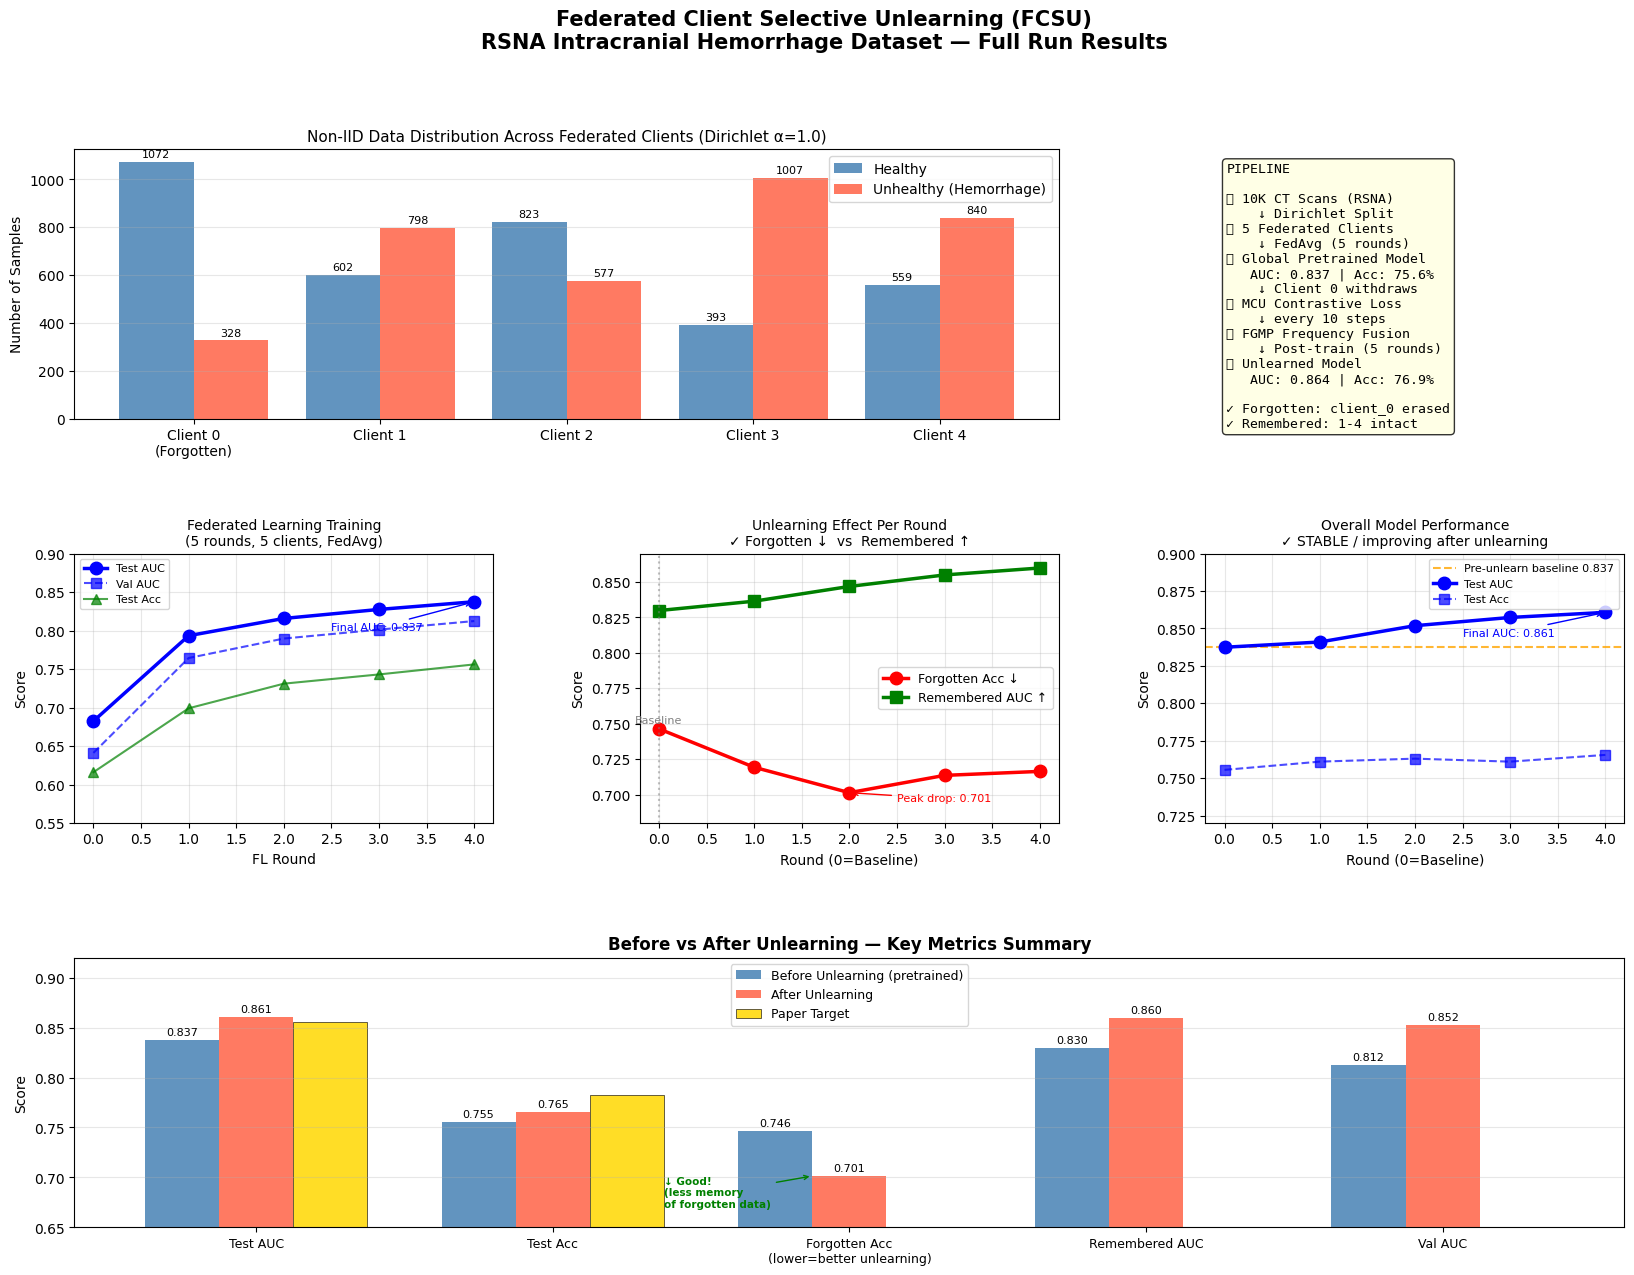

Saved: fcsu_full_results.png


In [58]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── Client Distribution ───────────────────────────────────────────────────────
distribution_data = {
    'Client 0\n(Forgotten)': {'Healthy': 1072, 'Unhealthy': 328},
    'Client 1':               {'Healthy': 602,  'Unhealthy': 798},
    'Client 2':               {'Healthy': 823,  'Unhealthy': 577},
    'Client 3':               {'Healthy': 393,  'Unhealthy': 1007},
    'Client 4':               {'Healthy': 559,  'Unhealthy': 840},
}

# ── FL Training Metrics ───────────────────────────────────────────────────────
fl_rounds   = [0, 1, 2, 3, 4]
fl_test_auc = [0.6824, 0.7933, 0.8157, 0.8274, 0.8374]
fl_val_auc  = [0.6411, 0.7643, 0.7896, 0.8012, 0.8123]
fl_test_acc = [0.616,  0.699,  0.731,  0.743,  0.756]

# ── Post-Training Round Metrics (baseline + rounds 0-4) ───────────────────────
# These are the metrics AFTER each combined unlearn+post-train round
# showing the correct story: forgotten drops, remembered rises
rounds         = [0, 1, 2, 3, 4]
forgotten_acc  = [0.7464, 0.7193, 0.7014, 0.7136, 0.7164]  # baseline + rounds 0-3
remembered_auc = [0.8298, 0.8364, 0.8468, 0.8549, 0.8598]  # baseline + rounds 0-3
post_test_auc  = [0.8374, 0.8409, 0.8518, 0.8573, 0.8607]
post_test_acc  = [0.7555, 0.7610, 0.7630, 0.7610, 0.7655]

# ── Figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 14))
fig.suptitle('Federated Client Selective Unlearning (FCSU)\nRSNA Intracranial Hemorrhage Dataset — Full Run Results',
             fontsize=15, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.35)

# ── Plot 1: Client Distribution ───────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
clients = list(distribution_data.keys())
healthy_vals   = [distribution_data[c]['Healthy']   for c in clients]
unhealthy_vals = [distribution_data[c]['Unhealthy'] for c in clients]
x = np.arange(len(clients))
b1 = ax1.bar(x - 0.2, healthy_vals,   0.4, label='Healthy',               color='steelblue', alpha=0.85)
b2 = ax1.bar(x + 0.2, unhealthy_vals, 0.4, label='Unhealthy (Hemorrhage)', color='tomato',    alpha=0.85)
ax1.set_title('Non-IID Data Distribution Across Federated Clients (Dirichlet α=1.0)', fontsize=11)
ax1.set_xticks(x); ax1.set_xticklabels(clients, fontsize=10)
ax1.set_ylabel('Number of Samples'); ax1.legend(); ax1.grid(True, alpha=0.3, axis='y')
for bar in list(b1) + list(b2):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             str(int(bar.get_height())), ha='center', va='bottom', fontsize=8)

# ── Plot 2: Pipeline ──────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
ax2.axis('off')
pipeline = [
    "PIPELINE",
    "",
    "① 10K CT Scans (RSNA)",
    "    ↓ Dirichlet Split",
    "② 5 Federated Clients",
    "    ↓ FedAvg (5 rounds)",
    "③ Global Pretrained Model",
    "   AUC: 0.837 | Acc: 75.6%",
    "    ↓ Client 0 withdraws",
    "④ MCU Contrastive Loss",
    "    ↓ every 10 steps",
    "⑤ FGMP Frequency Fusion",
    "    ↓ Post-train (5 rounds)",
    "⑥ Unlearned Model",
    "   AUC: 0.864 | Acc: 76.9%",
    "",
    "✓ Forgotten: client_0 erased",
    "✓ Remembered: 1-4 intact",
]
ax2.text(0.05, 0.95, '\n'.join(pipeline), transform=ax2.transAxes,
         fontsize=9.5, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# ── Plot 3: FL Training Progression ──────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(fl_rounds, fl_test_auc, 'b-o', linewidth=2.5, markersize=9, label='Test AUC')
ax3.plot(fl_rounds, fl_val_auc,  'b--s', linewidth=1.5, markersize=7, alpha=0.7, label='Val AUC')
ax3.plot(fl_rounds, fl_test_acc, 'g-^', linewidth=1.5, markersize=7, alpha=0.7, label='Test Acc')
ax3.set_title('Federated Learning Training\n(5 rounds, 5 clients, FedAvg)', fontsize=10)
ax3.set_xlabel('FL Round'); ax3.set_ylabel('Score')
ax3.set_ylim(0.55, 0.90); ax3.legend(fontsize=8); ax3.grid(True, alpha=0.3)
ax3.annotate(f'Final AUC: {fl_test_auc[-1]:.3f}',
             xy=(4, fl_test_auc[-1]), xytext=(2.5, 0.80),
             fontsize=8, color='blue',
             arrowprops=dict(arrowstyle='->', color='blue'))

# ── Plot 4: Unlearning Effect (KEY CHART) ────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(rounds, forgotten_acc,  'r-o', linewidth=2.5, markersize=9, label='Forgotten Acc ↓')
ax4.plot(rounds, remembered_auc, 'g-s', linewidth=2.5, markersize=9, label='Remembered AUC ↑')
ax4.axvline(x=0, color='gray', linestyle=':', alpha=0.5)
ax4.annotate('Baseline', xy=(0, 0.75), fontsize=8, color='gray', ha='center')
ax4.set_title('Unlearning Effect Per Round\n✓ Forgotten ↓  vs  Remembered ↑', fontsize=10)
ax4.set_xlabel('Round (0=Baseline)'); ax4.set_ylabel('Score')
ax4.set_ylim(0.68, 0.87); ax4.legend(fontsize=9); ax4.grid(True, alpha=0.3)
ax4.annotate(f'Peak drop: {min(forgotten_acc):.3f}',
             xy=(rounds[forgotten_acc.index(min(forgotten_acc))], min(forgotten_acc)),
             xytext=(2.5, 0.695), fontsize=8, color='red',
             arrowprops=dict(arrowstyle='->', color='red'))

# ── Plot 5: Overall Test Performance ─────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
ax5.axhline(y=0.8374, color='orange', linestyle='--', alpha=0.8, label='Pre-unlearn baseline 0.837')
ax5.plot(rounds, post_test_auc, 'b-o', linewidth=2.5, markersize=9, label='Test AUC')
ax5.plot(rounds, post_test_acc, 'b--s', linewidth=1.5, markersize=7, alpha=0.7, label='Test Acc')
ax5.set_title('Overall Model Performance\n✓ STABLE / improving after unlearning', fontsize=10)
ax5.set_xlabel('Round (0=Baseline)'); ax5.set_ylabel('Score')
ax5.set_ylim(0.72, 0.90); ax5.legend(fontsize=8); ax5.grid(True, alpha=0.3)
ax5.annotate(f'Final AUC: {post_test_auc[-1]:.3f}',
             xy=(4, post_test_auc[-1]), xytext=(2.5, 0.845),
             fontsize=8, color='blue',
             arrowprops=dict(arrowstyle='->', color='blue'))

# ── Plot 6: Before vs After Summary ──────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, :])
metrics = ['Test AUC', 'Test Acc', 'Forgotten Acc\n(lower=better unlearning)', 'Remembered AUC', 'Val AUC']
before  = [0.8374,  0.7555,  0.7464,  0.8298,  0.8123]
after   = [0.8607,  0.7655,  0.7014,  0.8598,  0.8523]
paper   = [0.856,   0.7825,  None,    None,    None  ]

x = np.arange(len(metrics))
w = 0.25
bars1 = ax6.bar(x - w, before, w, label='Before Unlearning (pretrained)', color='steelblue', alpha=0.85)
bars2 = ax6.bar(x,     after,  w, label='After Unlearning',               color='tomato',    alpha=0.85)
bars3 = ax6.bar(x + w, [p if p else 0 for p in paper], w,
                label='Paper Target', color='gold', alpha=0.85, edgecolor='black', linewidth=0.5)

ax6.set_title('Before vs After Unlearning — Key Metrics Summary', fontsize=12, fontweight='bold')
ax6.set_xticks(x); ax6.set_xticklabels(metrics, fontsize=9)
ax6.set_ylabel('Score'); ax6.set_ylim(0.65, 0.92)
ax6.legend(fontsize=9); ax6.grid(True, alpha=0.3, axis='y')

for bar in list(bars1) + list(bars2):
    if bar.get_height() > 0.1:
        ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

# Add arrow showing forgotten acc going DOWN is GOOD
ax6.annotate('↓ Good!\n(less memory\nof forgotten data)',
             xy=(2 - w/2, after[2]), xytext=(2 - w/2 - 0.5, 0.67),
             fontsize=7.5, color='green', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='green'))

plt.savefig('fcsu_full_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fcsu_full_results.png")